# Bloque 3. Formatos avanzados para ML

**Modulo ETCDFM (5104) - UD2: Formatos de fichero de datos**

---

CSV y Excel cubren bien el intercambio de datos entre personas, pero se quedan cortos cuando los datasets tienen millones de filas o cuando el rendimiento importa. En este bloque estudiamos los formatos binarios que dominan los pipelines de ML modernos: **Parquet**, **HDF5** y **Apache Arrow/Feather**.


## Contenidos

1. Limitaciones de CSV con datasets grandes
2. Parquet: diseno columnar, compresion y esquema integrado
3. Lectura y escritura: `read_parquet`, `to_parquet`
4. Particionado en Parquet
5. HDF5: estructura jerarquica para datos cientificos y deep learning
6. Apache Arrow y Feather: estandar en memoria y en disco
7. Otros formatos binarios: Avro, Protobuf, MessagePack
8. Benchmark comparativo


## 3.1 Limitaciones de CSV con datasets grandes

CSV funciona bien hasta cierto punto. Con datasets de millones de filas aparecen problemas:

| Limitacion | Impacto |
|---|---|
| Sin esquema integrado | Los tipos se reinfieren en cada lectura |
| Orientado a filas | Leer 2 columnas requiere parsear todas |
| Sin compresion nativa | Ocupa mucho mas espacio que formatos binarios |
| Parsing lento | Convertir texto a numeros tiene coste alto |
| Sin soporte de indexado | No hay acceso aleatorio eficiente |
| Nulos ambiguos | Vacio, 'NULL', 'NaN'... sin distincion de tipo |

> **Nuestro dataset**: 30 000 filas, 11 columnas. CSV ocupa 2.4 MB; Parquet (zstd) ocupa 0.6 MB y se lee mas rapido.


In [1]:
import pandas as pd, time, os

formatos = [
    ('CSV',              'datos/ventas_grande.csv',
     lambda: pd.read_csv('datos/ventas_grande.csv')),
    ('Parquet (gzip)',   'datos/ventas_grande_gzip.parquet',
     lambda: pd.read_parquet('datos/ventas_grande_gzip.parquet')),
    ('Parquet (snappy)', 'datos/ventas_grande_snappy.parquet',
     lambda: pd.read_parquet('datos/ventas_grande_snappy.parquet')),
    ('Parquet (zstd)',   'datos/ventas_grande_zstd.parquet',
     lambda: pd.read_parquet('datos/ventas_grande_zstd.parquet')),
    ('Feather (Arrow)',  'datos/ventas_grande.feather',
     lambda: pd.read_feather('datos/ventas_grande.feather')),
]

print(f"{'Formato':<22} {'Tamano':>10}  {'Lectura':>8}  Ahorro vs CSV")
print('-' * 62)
csv_size = os.path.getsize('datos/ventas_grande.csv')
csv_t = None
for nombre, path, fn in formatos:
    size = os.path.getsize(path)
    t0 = time.perf_counter()
    for _ in range(3): fn()
    t = (time.perf_counter() - t0) / 3
    if csv_t is None: csv_t = t
    ratio_sz = csv_size / size
    speedup  = csv_t / t
    print(f'{nombre:<22} {size/1024:>8.0f} KB  {t*1000:>6.0f} ms  '
          f'{ratio_sz:>5.1f}x menor, {speedup:>4.1f}x mas rapido')


Formato                    Tamano   Lectura  Ahorro vs CSV
--------------------------------------------------------------
CSV                        2388 KB      49 ms    1.0x menor,  1.0x mas rapido
Parquet (gzip)              636 KB     199 ms    3.8x menor,  0.2x mas rapido
Parquet (snappy)            868 KB      19 ms    2.8x menor,  2.6x mas rapido
Parquet (zstd)              573 KB      22 ms    4.2x menor,  2.3x mas rapido
Feather (Arrow)            1648 KB      18 ms    1.4x menor,  2.7x mas rapido


C:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\pandas\io\feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(
C:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\pandas\io\feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(
C:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\pandas\io\feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(


## 3.2 Parquet: diseno columnar y esquema integrado

Apache Parquet es un formato **binario columnar** con esquema integrado, disenado para analisis de datos a gran escala.

**Caracteristicas clave:**
- **Columnar**: los valores de cada columna se almacenan juntos. Se pueden leer solo las columnas necesarias sin tocar el resto.
- **Esquema integrado**: el fichero incluye la definicion de tipos de todas las columnas. No hay ambiguedad de tipos.
- **Row groups**: el fichero se divide en bloques de filas (~128 MB). Facilita la lectura paralela.
- **Estadisticas por columna**: min, max y recuento de nulos por row group. Permiten saltar bloques sin leerlos (*predicate pushdown*).
- **Compresion independiente**: cada columna se comprime con el algoritmo optimo para su tipo.


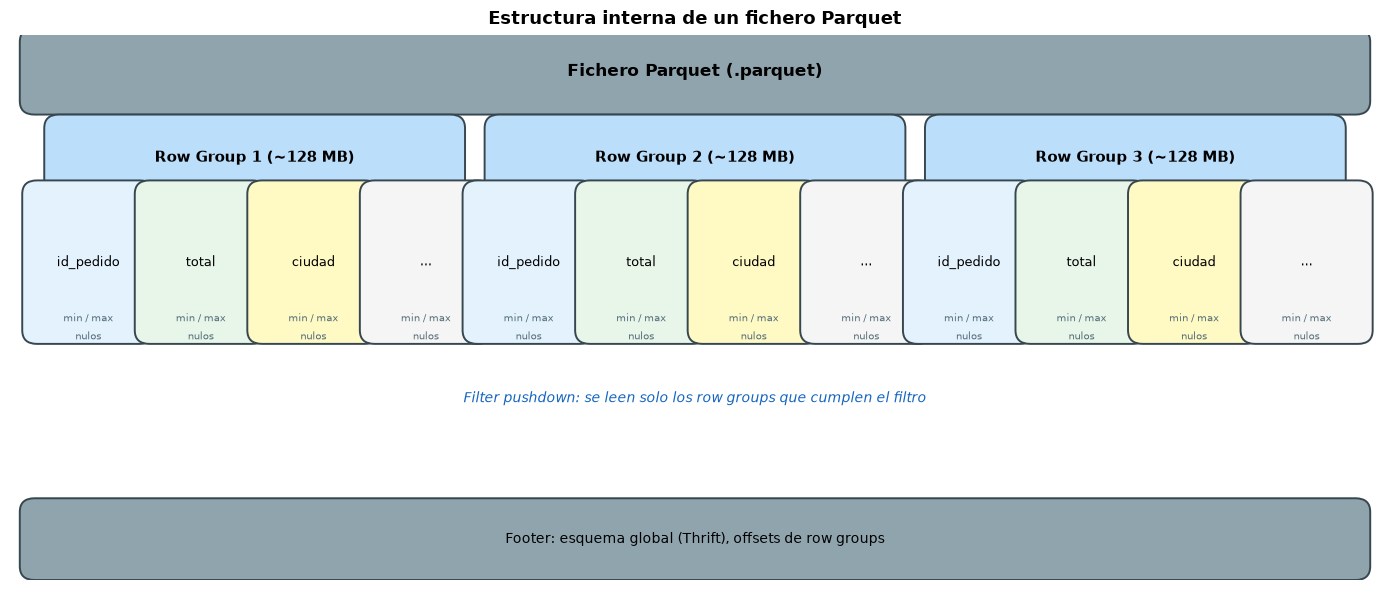

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14); ax.set_ylim(0, 6); ax.axis('off')

def box(ax, x, y, w, h, lbl, clr, fs=10, bold=False):
    p = FancyBboxPatch((x-w/2, y-h/2), w, h,
                       boxstyle='round,pad=0.15', lw=1.4,
                       edgecolor='#37474F', facecolor=clr, zorder=3)
    ax.add_patch(p)
    fw = 'bold' if bold else 'normal'
    ax.text(x, y, lbl, ha='center', va='center', fontsize=fs, fontweight=fw, zorder=4)

box(ax, 7, 5.6, 13.5, 0.65, 'Fichero Parquet (.parquet)', '#90A4AE', fs=12, bold=True)
box(ax, 7, 0.45, 13.5, 0.6,
    'Footer: esquema global (Thrift), offsets de row groups', '#90A4AE', fs=10)

grps = [(2.5, 'Row Group 1'), (7.0, 'Row Group 2'), (11.5, 'Row Group 3')]
for gx, glbl in grps:
    box(ax, gx, 4.65, 4.0, 0.65, glbl + ' (~128 MB)', '#BBDEFB', fs=11, bold=True)
    cols_info = [('id_pedido','#E3F2FD'),('total','#E8F5E9'),
                 ('ciudad','#FFF9C4'),('...','#F5F5F5')]
    for ci, (clbl, cclr) in enumerate(cols_info):
        cx = gx - 1.7 + ci * 1.15
        box(ax, cx, 3.5, 1.05, 1.5, clbl, cclr, fs=9)
        ax.text(cx, 2.88, 'min / max', ha='center', va='center', fontsize=7.5, color='#546E7A')
        ax.text(cx, 2.68, 'nulos', ha='center', va='center', fontsize=7.5, color='#546E7A')
    ax.plot([gx, gx], [4.33, 4.2], color='#78909C', lw=1)

ax.text(7, 2.0,
        'Filter pushdown: se leen solo los row groups que cumplen el filtro',
        ha='center', va='center', fontsize=10, style='italic', color='#1565C0')

plt.title('Estructura interna de un fichero Parquet', fontsize=13, fontweight='bold', pad=8)
plt.tight_layout(); plt.show()


## Compresion en Parquet

| Algoritmo | Ratio | Velocidad | Cuando usarlo |
|---|---|---|---|
| **Snappy** | Moderado | Muy rapida | Procesamiento interactivo, Spark |
| **Gzip** | Alto | Moderada | Almacenamiento a largo plazo |
| **Zstd** | Muy alto | Rapida | Equilibrio optimo (recomendado 2025) |
| `None` | Sin compresion | Maxima | RAM abundante, SSD rapido |

```python
df.to_parquet('datos.parquet', compression='zstd')   # recomendado
df.to_parquet('datos.parquet', compression='snappy') # compatible Spark
df.to_parquet('datos.parquet', compression=None)     # sin compresion
```

La compresion se aplica **por columna** de forma independiente. Para columnas de texto se usa codificacion por diccionario antes de comprimir.


In [3]:
import pandas as pd, time

# Lectura basica: el esquema se preserva
df = pd.read_parquet('datos/ventas_grande_zstd.parquet')
print(f'Shape: {df.shape}  |  Tipos:')
print(df.dtypes)
print()

# Projection pushdown: leer solo columnas necesarias
COLS = ['id_pedido', 'total', 'ciudad']
t0 = time.perf_counter()
df_full = pd.read_parquet('datos/ventas_grande_gzip.parquet')
t_full = time.perf_counter() - t0

t0 = time.perf_counter()
df_proj = pd.read_parquet('datos/ventas_grande_gzip.parquet', columns=COLS)
t_proj = time.perf_counter() - t0

mem_full = df_full.memory_usage(deep=True).sum()
mem_proj = df_proj.memory_usage(deep=True).sum()
print(f'Lectura completa  ({df_full.shape[1]} cols): {t_full*1000:.0f} ms  {mem_full:,} bytes RAM')
print(f'Projection ({len(COLS)} cols):         {t_proj*1000:.0f} ms  {mem_proj:,} bytes RAM')

# Filter pushdown (predicate pushdown)
import pyarrow.parquet as pq
t0 = time.perf_counter()
df_filt = pq.read_table('datos/ventas_grande_gzip.parquet',
                         filters=[('ciudad', '=', 'Madrid')]).to_pandas()
t_filt = time.perf_counter() - t0
print(f'Filter pushdown (ciudad=Madrid): {t_filt*1000:.0f} ms  {len(df_filt)} filas')


Shape: (30000, 11)  |  Tipos:
id_pedido        int64
fecha           object
producto_id      int64
categoria       object
cantidad         int64
precio_unit    float64
total          float64
ciudad          object
region          object
metodo_pago     object
descuento      float64
dtype: object

Lectura completa  (11 cols): 21 ms  10,236,311 bytes RAM
Projection (3 cols):         8 ms  2,168,858 bytes RAM
Filter pushdown (ciudad=Madrid): 24 ms  3058 filas


## 3.4 Particionado en Parquet

El **particionado** divide el dataset en ficheros organizados en carpetas segun los valores de una columna. Es el estandar en data lakes.

```
ventas_parquet/
   region=Com. Madrid/  ->  part-0.parquet
   region=Cataluna/     ->  part-0.parquet
   region=Andalucia/    ->  part-0.parquet
```

Al filtrar por `region='Cataluna'`, solo se lee esa subcarpeta. En datasets de miles de millones de filas esto reduce el tiempo de consulta de horas a segundos.

- **Columnas de particion**: elegir columnas con cardinalidad baja (region, ano, categoria).
- **Herramientas compatibles**: pandas, pyarrow, Spark, DuckDB, Polars, Athena, BigQuery.


In [4]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import os, glob

df = pd.read_parquet('datos/ventas_grande_gzip.parquet')

# Escribir particionado por region
PART = '/tmp/ventas_parquet'
tabla = pa.Table.from_pandas(df, preserve_index=False)
pq.write_to_dataset(tabla, root_path=PART, partition_cols=['region'])

print('Estructura del dataset particionado:')
for f in sorted(glob.glob(f'{PART}/**/*.parquet', recursive=True)):
    rel = f.replace(PART, '')
    size = os.path.getsize(f)
    print(f'  {rel:<45} {size:>7,} bytes')

# Leer solo una particion
df_cat = pq.read_table(PART,
                        filters=[('region', '=', 'Cataluna')]).to_pandas()
print(f'\nLeer region=Cataluna: {len(df_cat)} filas')

# Con pandas directamente
df_and = pd.read_parquet(PART, filters=[('region', '=', 'Andalucia')])
print(f'Leer region=Andalucia: {len(df_and)} filas')


Estructura del dataset particionado:
  \region=Andalucia\f5705520784643af80995d4319b46405-0.parquet 274,382 bytes
  \region=Aragon\f5705520784643af80995d4319b46405-0.parquet  93,893 bytes
  \region=C.%20Valenciana\f5705520784643af80995d4319b46405-0.parquet  94,732 bytes
  \region=C.%20y%20Leon\f5705520784643af80995d4319b46405-0.parquet  96,338 bytes
  \region=Cataluna\f5705520784643af80995d4319b46405-0.parquet  95,635 bytes
  \region=Com.%20Madrid\f5705520784643af80995d4319b46405-0.parquet  97,865 bytes
  \region=Pais%20Vasco\f5705520784643af80995d4319b46405-0.parquet  96,075 bytes
  \region=R.%20Murcia\f5705520784643af80995d4319b46405-0.parquet  97,416 bytes

Leer region=Cataluna: 2979 filas
Leer region=Andalucia: 9047 filas


## 3.5 HDF5: estructura jerarquica para datos cientificos

**HDF5** organiza los datos en una jerarquia de **grupos** (como carpetas) y **datasets** (arrays n-dimensionales con metadatos).

```
dataset_dl.h5
   X_train  [5000 x 64, float32, gzip]
   y_train  [5000, int32]
   X_test   [1000 x 64, float32]
   y_test   [1000, int32]
   metadatos/              (grupo)
      @n_clases = 10
      @version  = '1.0'
```

**Casos de uso en ML:**
- Almacenar pesos de redes neuronales (Keras guarda `.h5`)
- Datasets de imagenes o audio como arrays numpy con compresion
- Acceso parcial sin cargar todo en RAM (*lazy loading*)
- Datos cientificos multidimensionales (simulaciones, experimentos)


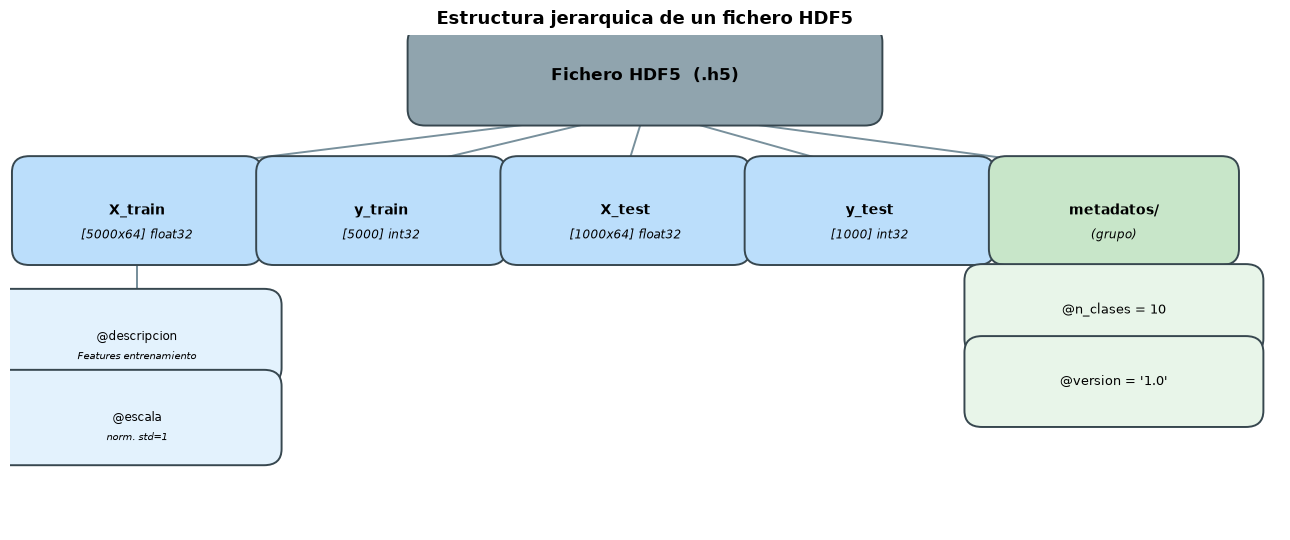

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 5.5); ax.axis('off')

def box(ax, x, y, w, h, lbl, clr, fs=10, bold=False):
    p = FancyBboxPatch((x-w/2, y-h/2), w, h,
                       boxstyle='round,pad=0.18', lw=1.4,
                       edgecolor='#37474F', facecolor=clr, zorder=3)
    ax.add_patch(p)
    fw = 'bold' if bold else 'normal'
    ax.text(x, y, lbl, ha='center', va='center', fontsize=fs, fontweight=fw, zorder=4)

def edge(ax, x1, y1, x2, y2):
    ax.plot([x1, x2], [y1, y2], color='#78909C', lw=1.4, zorder=1)

box(ax, 6.5, 5.05, 4.5, 0.75, 'Fichero HDF5  (.h5)', '#90A4AE', fs=12, bold=True)

ds1 = [
    (1.3, 3.55, 'X_train', '[5000x64] float32', '#BBDEFB'),
    (3.8, 3.55, 'y_train', '[5000] int32',      '#BBDEFB'),
    (6.3, 3.55, 'X_test',  '[1000x64] float32', '#BBDEFB'),
    (8.8, 3.55, 'y_test',  '[1000] int32',      '#BBDEFB'),
    (11.3, 3.55, 'metadatos/', '(grupo)',        '#C8E6C9'),
]
for x, y, lbl, sub, clr in ds1:
    box(ax, x, y, 2.2, 0.85, lbl, clr, fs=10, bold=True)
    ax.text(x, y-0.27, sub, ha='center', va='center', fontsize=8.5, style='italic', zorder=4)
    edge(ax, 6.5, 4.67, x, 3.97)

for i, (k, v) in enumerate([('@descripcion', 'Features entrenamiento'), ('@escala', 'norm. std=1')]):
    box(ax, 1.3, 2.15 - i*0.9, 2.6, 0.7, k, '#E3F2FD', fs=8.5)
    ax.text(1.3, 2.15 - i*0.9 - 0.22, v, ha='center', va='center', fontsize=7.5, style='italic', zorder=4)
    edge(ax, 1.3, 3.12, 1.3, 2.5 - i*0.9)

box(ax, 11.3, 2.45, 2.7, 0.65, '@n_clases = 10', '#E8F5E9', fs=9)
box(ax, 11.3, 1.65, 2.7, 0.65, "@version = '1.0'", '#E8F5E9', fs=9)
edge(ax, 11.3, 3.12, 11.3, 2.78)
edge(ax, 11.3, 3.12, 11.3, 1.97)

plt.title('Estructura jerarquica de un fichero HDF5', fontsize=13, fontweight='bold', pad=8)
plt.tight_layout(); plt.show()


## HDF5 con h5py: lectura y escritura de arrays numpy

```python
import h5py, numpy as np

# Escritura
with h5py.File('modelo.h5', 'w') as hf:
    hf.create_dataset('X_train', data=X, compression='gzip')
    hf['X_train'].attrs['descripcion'] = 'features normalizadas'
    grp = hf.create_group('metadatos')
    grp.attrs['n_clases'] = 10

# Lectura
with h5py.File('modelo.h5', 'r') as hf:
    X = hf['X_train'][:]          # cargar todo
    X_batch = hf['X_train'][:64]  # acceso parcial (lazy)
```

**Ventaja del lazy loading:**
Un dataset de 50 GB en disco se puede usar para entrenar leyendo un *batch* de 64 muestras en cada iteracion sin cargar el fichero completo en RAM.


In [6]:
import h5py, numpy as np

# Explorar la estructura
with h5py.File('datos/dataset_dl.h5', 'r') as hf:
    print('Estructura del HDF5:')
    def mostrar(nombre, obj):
        indent = '  ' * nombre.count('/')
        if isinstance(obj, h5py.Dataset):
            print(f'{indent}/{nombre}: shape={obj.shape} dtype={obj.dtype}')
        else:
            print(f'{indent}/{nombre}/ (grupo)')
    hf.visititems(mostrar)

    X_train = hf['X_train'][:]
    y_train = hf['y_train'][:]
    print(f'\nX_train: {X_train.shape}  media={X_train.mean():.4f}')
    print(f'y_train: {y_train.shape}  clases={np.unique(y_train)}')

    # Acceso parcial: primer batch de 32 muestras
    X_batch = hf['X_train'][:32]
    print(f'\nPrimer batch (lazy loading): {X_batch.shape}')

    print(f'\nAtributos X_train: {dict(hf["X_train"].attrs)}')
    print(f'Atributos metadatos: {dict(hf["metadatos"].attrs)}')

# Escritura de nuevo fichero
X_nuevo = np.random.randn(100, 32).astype('float32')
with h5py.File('/tmp/demo.h5', 'w') as hf:
    hf.create_dataset('features', data=X_nuevo, compression='gzip', chunks=(10, 32))
    hf['features'].attrs['autor'] = 'ETCDFM'
print('\nEscritura OK  ->  /tmp/demo.h5')


Estructura del HDF5:
/X_test: shape=(1000, 64) dtype=float32
/X_train: shape=(5000, 64) dtype=float32
/metadatos/ (grupo)
/y_test: shape=(1000,) dtype=int32
/y_train: shape=(5000,) dtype=int32

X_train: (5000, 64)  media=-0.0016
y_train: (5000,)  clases=[0 1 2 3 4 5 6 7 8 9]

Primer batch (lazy loading): (32, 64)

Atributos X_train: {'descripcion': 'Features de entrenamiento'}
Atributos metadatos: {'n_clases': np.int64(10), 'version': '1.0'}

Escritura OK  ->  /tmp/demo.h5


## 3.6 Apache Arrow: estandar de datos en memoria

**Apache Arrow** define un formato columnar **en RAM** que permite compartir datos entre herramientas sin copiarlos (*zero-copy*).

**Sin Arrow**: cada herramienta usa su propio formato interno. Pasar datos de pandas a Spark requiere serializar, transferir y deserializar.

**Con Arrow**: todas las herramientas leen del mismo buffer de memoria. No hay copia, no hay conversion.

```
pandas 2.0  ---  memoria Arrow  --->  DuckDB / Polars / PySpark
                  (zero-copy, sin serializar)
```

**Herramientas que usan Arrow internamente:**
pandas 2.0, DuckDB, Polars, PySpark, R (arrow), Dask, Ray, Ibis.

La API Python es **PyArrow** (`import pyarrow as pa`). Desde pandas 2.0, los DataFrames pueden usar Arrow como backend nativo.


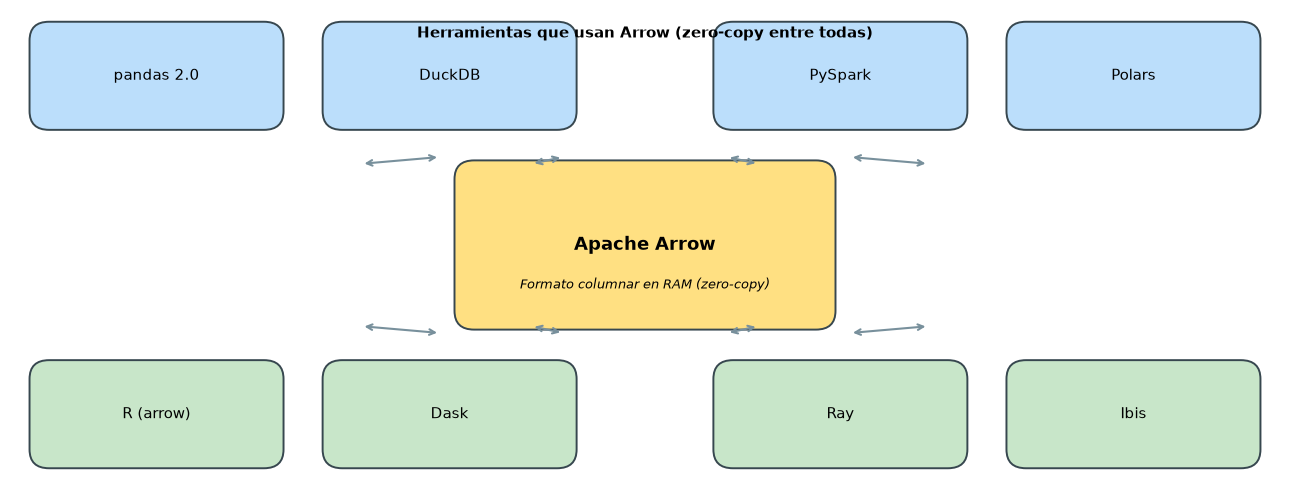

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 13); ax.set_ylim(0, 5); ax.axis('off')

def box(ax, x, y, w, h, lbl, clr, fs=10, bold=False):
    p = FancyBboxPatch((x-w/2, y-h/2), w, h,
                       boxstyle='round,pad=0.2', lw=1.4,
                       edgecolor='#37474F', facecolor=clr, zorder=3)
    ax.add_patch(p)
    fw = 'bold' if bold else 'normal'
    ax.text(x, y, lbl, ha='center', va='center', fontsize=fs, fontweight=fw, zorder=4)

box(ax, 6.5, 2.5, 3.5, 1.4, 'Apache Arrow', '#FFE082', fs=13, bold=True)
ax.text(6.5, 2.08, 'Formato columnar en RAM (zero-copy)', ha='center', va='center',
        fontsize=9, style='italic', zorder=4)

tools = [
    (1.5, 4.3, 'pandas 2.0', '#BBDEFB'), (4.5, 4.3, 'DuckDB',    '#BBDEFB'),
    (8.5, 4.3, 'PySpark',   '#BBDEFB'), (11.5, 4.3, 'Polars',    '#BBDEFB'),
    (1.5, 0.7, 'R (arrow)', '#C8E6C9'), (4.5,  0.7, 'Dask',      '#C8E6C9'),
    (8.5, 0.7, 'Ray',       '#C8E6C9'), (11.5, 0.7, 'Ibis',      '#C8E6C9'),
]
for x, y, lbl, clr in tools:
    box(ax, x, y, 2.2, 0.75, lbl, clr, fs=11)
    ax.annotate('', xy=(6.5+(x-6.5)*0.42, 2.5+(y-2.5)*0.52),
                xytext=(x+(6.5-x)*0.42, y+(2.5-y)*0.52),
                arrowprops=dict(arrowstyle='<->', color='#78909C', lw=1.5))

ax.text(6.5, 4.75, 'Herramientas que usan Arrow (zero-copy entre todas)',
        ha='center', va='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


## Feather: Arrow serializado en disco

**Feather** (Arrow IPC File Format) es Arrow guardado en disco. Disenado para intercambio rapido entre procesos o entre Python y R.

```python
df.to_feather('datos.feather')                    # escritura
df = pd.read_feather('datos.feather')             # lectura
df = pd.read_feather('datos.feather',             # lectura selectiva
                     columns=['id', 'total'])
```

| | Feather | Parquet |
|---|---|---|
| Velocidad lectura | Muy alta | Alta |
| Compresion | LZ4 / Zstd | Snappy / Gzip / Zstd |
| Particionado | No | Si |
| Esquema integrado | Si | Si |
| Uso ideal | Cache intermedio, IPC | Data lake, largo plazo |


In [8]:
import pandas as pd, time, os

# Comparar Feather vs CSV en lectura
t0 = time.perf_counter()
df_f = pd.read_feather('datos/ventas_grande.feather')
t_f = time.perf_counter() - t0

t0 = time.perf_counter()
df_c = pd.read_csv('datos/ventas_grande.csv')
t_c = time.perf_counter() - t0

sz_f = os.path.getsize('datos/ventas_grande.feather') / 1024
sz_c = os.path.getsize('datos/ventas_grande.csv') / 1024
print(f'Feather: {t_f*1000:.0f} ms  {sz_f:.0f} KB')
print(f'CSV:     {t_c*1000:.0f} ms  {sz_c:.0f} KB')
print(f'Feather es {t_c/t_f:.1f}x mas rapido en lectura')

# Los tipos se preservan sin inferencia
print(f'\nTipos en Feather:')
print(df_f.dtypes)

# Lectura selectiva de columnas
df_sel = pd.read_feather('datos/ventas_grande.feather',
                          columns=['id_pedido', 'total', 'ciudad'])
print(f'\nLectura selectiva (3 cols): {df_sel.shape}')

# Interoperabilidad: convertir a Arrow Table
import pyarrow as pa
tabla = pa.Table.from_pandas(df_f)
print(f'\nArrow Table schema (primeras 4 columnas):')
for i, field in enumerate(tabla.schema):
    if i < 4: print(f'  {field.name}: {field.type}')
    if i == 4: print('  ...')


C:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\pandas\io\feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(


Feather: 30 ms  1648 KB
CSV:     68 ms  2388 KB
Feather es 2.2x mas rapido en lectura

Tipos en Feather:
id_pedido        int64
fecha           object
producto_id      int64
categoria       object
cantidad         int64
precio_unit    float64
total          float64
ciudad          object
region          object
metodo_pago     object
descuento      float64
dtype: object

Lectura selectiva (3 cols): (30000, 3)

Arrow Table schema (primeras 4 columnas):
  id_pedido: int64
  fecha: string
  producto_id: int64
  categoria: string
  ...


C:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\pandas\io\feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(


## 3.7 Otros formatos binarios: Avro, Protobuf, MessagePack

| Formato | Orientacion | Esquema | Ecosistema | Cuando usarlo |
|---|---|---|---|---|
| **Avro** | Filas | Obligatorio (JSON Schema) | Kafka, Confluent | Streaming de eventos |
| **Protobuf** | Filas | Obligatorio (.proto) | gRPC, TensorFlow | Microservicios, modelos ML |
| **MessagePack** | Filas | Opcional | APIs internas, Redis | Serializacion de objetos |

**Avro** y **Protobuf** son esenciales en arquitecturas de datos en tiempo real. No se usan con pandas directamente, sino como formato de transporte entre servicios.

En ML, Protobuf es la base del formato `SavedModel` de TensorFlow y de los registros `tf.data.Dataset`.

> Para este modulo basta conocer su existencia y cuando se aplican. Los bloques 4 y 5 cubren XML y JSON, que son el equivalente en texto plano.


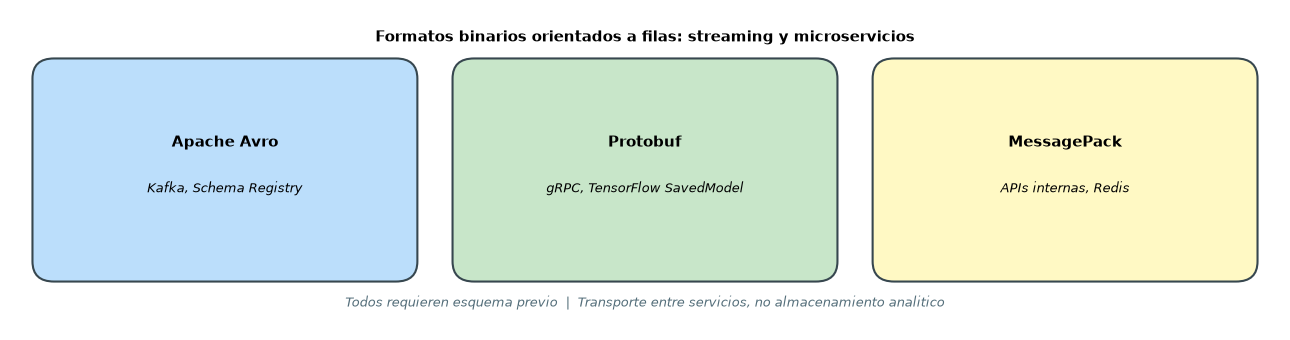

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 3.5); ax.axis('off')

def box(ax, x, y, w, h, t, sub, clr, fs=11):
    p = FancyBboxPatch((x-w/2, y-h/2), w, h,
                       boxstyle='round,pad=0.22', lw=1.5,
                       edgecolor='#37474F', facecolor=clr, zorder=3)
    ax.add_patch(p)
    ax.text(x, y+0.3, t,   ha='center', va='center', fontsize=fs, fontweight='bold', zorder=4)
    ax.text(x, y-0.2, sub, ha='center', va='center', fontsize=9,  style='italic',    zorder=4)

items = [
    (2.2,  1.75, 3.5, 2.0, 'Apache Avro',  'Kafka, Schema Registry',    '#BBDEFB'),
    (6.5,  1.75, 3.5, 2.0, 'Protobuf',     'gRPC, TensorFlow SavedModel','#C8E6C9'),
    (10.8, 1.75, 3.5, 2.0, 'MessagePack',  'APIs internas, Redis',      '#FFF9C4'),
]
for args in items: box(ax, *args)

ax.text(6.5, 3.2,
        'Formatos binarios orientados a filas: streaming y microservicios',
        ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(6.5, 0.3,
        'Todos requieren esquema previo  |  Transporte entre servicios, no almacenamiento analitico',
        ha='center', va='center', fontsize=9, style='italic', color='#546E7A')
plt.tight_layout(); plt.show()


## 3.8 Benchmark comparativo

Comparamos sobre el mismo dataset de **30 000 filas, 11 columnas**:

- **Tamano en disco** (MB)
- **Lectura completa** (ms, media de 3 lecturas)
- **Lectura selectiva** (solo 3 de 11 columnas)

La lectura selectiva ilustra la ventaja del **projection pushdown**: en formatos columnares solo se leen los bytes de las columnas solicitadas.


C:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\pandas\io\feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(
C:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\pandas\io\feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(
C:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\pandas\io\feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(
C:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-pac

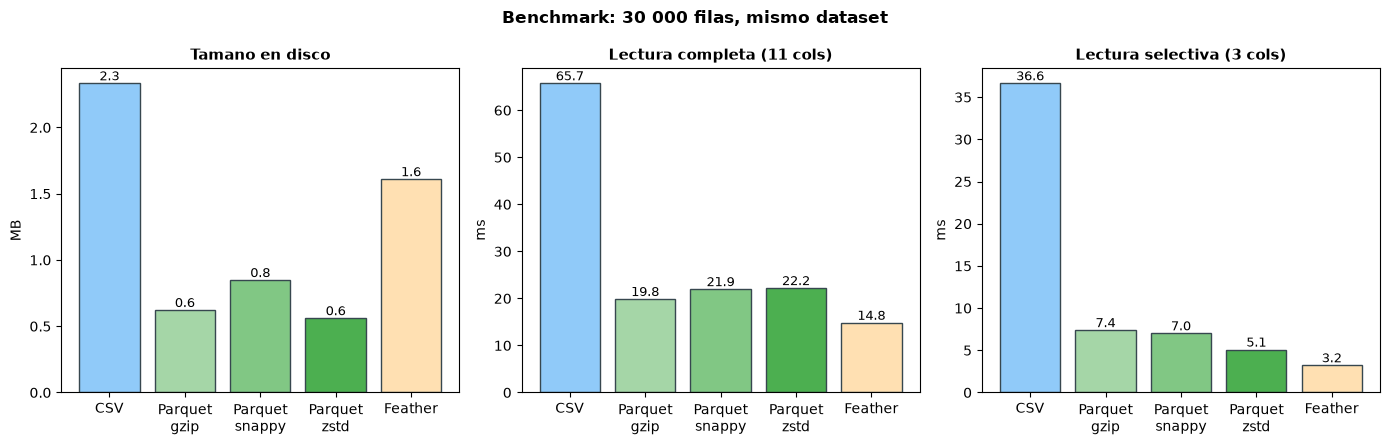

In [10]:
import pandas as pd, time, os
import matplotlib.pyplot as plt

COLS3 = ['id_pedido', 'total', 'ciudad']

configs = [
    ('CSV',
     'datos/ventas_grande.csv',
     lambda: pd.read_csv('datos/ventas_grande.csv'),
     lambda: pd.read_csv('datos/ventas_grande.csv', usecols=COLS3)),
    ('Parquet\ngzip',
     'datos/ventas_grande_gzip.parquet',
     lambda: pd.read_parquet('datos/ventas_grande_gzip.parquet'),
     lambda: pd.read_parquet('datos/ventas_grande_gzip.parquet', columns=COLS3)),
    ('Parquet\nsnappy',
     'datos/ventas_grande_snappy.parquet',
     lambda: pd.read_parquet('datos/ventas_grande_snappy.parquet'),
     lambda: pd.read_parquet('datos/ventas_grande_snappy.parquet', columns=COLS3)),
    ('Parquet\nzstd',
     'datos/ventas_grande_zstd.parquet',
     lambda: pd.read_parquet('datos/ventas_grande_zstd.parquet'),
     lambda: pd.read_parquet('datos/ventas_grande_zstd.parquet', columns=COLS3)),
    ('Feather',
     'datos/ventas_grande.feather',
     lambda: pd.read_feather('datos/ventas_grande.feather'),
     lambda: pd.read_feather('datos/ventas_grande.feather', columns=COLS3)),
]

nombres, sizes, t_full, t_sel = [], [], [], []
for nombre, path, fn_f, fn_s in configs:
    nombres.append(nombre)
    sizes.append(os.path.getsize(path) / 1024 / 1024)
    t0 = time.perf_counter()
    for _ in range(3): fn_f()
    t_full.append((time.perf_counter() - t0) / 3 * 1000)
    t0 = time.perf_counter()
    for _ in range(3): fn_s()
    t_sel.append((time.perf_counter() - t0) / 3 * 1000)

clrs = ['#90CAF9','#A5D6A7','#81C784','#4CAF50','#FFE0B2']
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, vals, titulo, unidad in [
    (axes[0], sizes,  'Tamano en disco', 'MB'),
    (axes[1], t_full, 'Lectura completa (11 cols)', 'ms'),
    (axes[2], t_sel,  'Lectura selectiva (3 cols)', 'ms'),
]:
    bars = ax.bar(nombres, vals, color=clrs, edgecolor='#37474F')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_ylabel(unidad)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+max(vals)*0.01,
                f'{v:.1f}', ha='center', fontsize=9)
plt.suptitle('Benchmark: 30 000 filas, mismo dataset', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


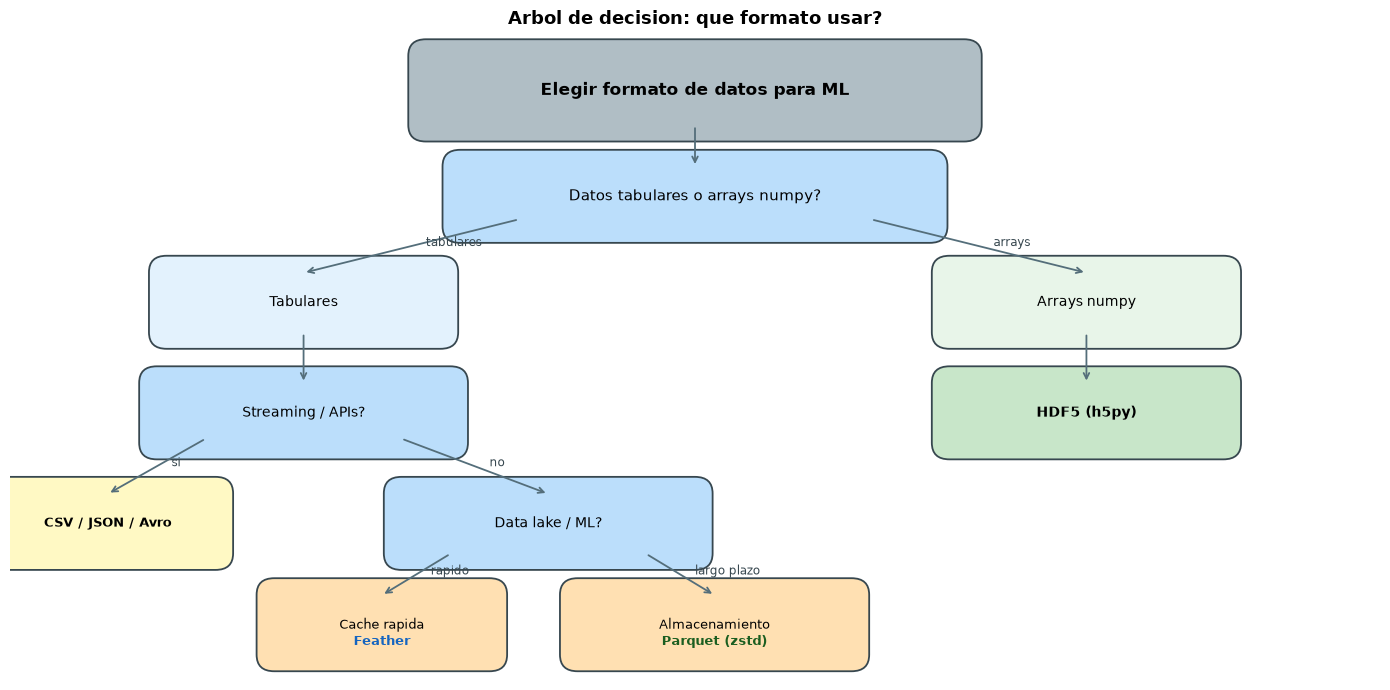

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 7); ax.axis('off')

def box(ax, x, y, w, h, lbl, clr, fs=10, bold=False):
    p = FancyBboxPatch((x-w/2, y-h/2), w, h,
                       boxstyle='round,pad=0.18', lw=1.3,
                       edgecolor='#37474F', facecolor=clr, zorder=3)
    ax.add_patch(p)
    fw = 'bold' if bold else 'normal'
    ax.text(x, y, lbl, ha='center', va='center', fontsize=fs, fontweight=fw, zorder=4)

def edge(ax, x1, y1, x2, y2, lbl=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#546E7A', lw=1.3))
    if lbl:
        ax.text((x1+x2)/2+0.15, (y1+y2)/2, lbl, fontsize=8.5, color='#37474F')

box(ax, 7, 6.4, 5.5, 0.75, 'Elegir formato de datos para ML', '#B0BEC5', fs=12, bold=True)
box(ax, 7, 5.25, 4.8, 0.65, 'Datos tabulares o arrays numpy?', '#BBDEFB', fs=11)
edge(ax, 7, 6.02, 7, 5.57)

box(ax, 3.0, 4.1, 2.8, 0.65, 'Tabulares', '#E3F2FD', fs=10)
box(ax, 11.0, 4.1, 2.8, 0.65, 'Arrays numpy', '#E8F5E9', fs=10)
edge(ax, 5.2, 5.0, 3.0, 4.42, 'tabulares')
edge(ax, 8.8, 5.0, 11.0, 4.42, 'arrays')

box(ax, 11.0, 2.9, 2.8, 0.65, 'HDF5 (h5py)', '#C8E6C9', fs=10, bold=True)
edge(ax, 11.0, 3.77, 11.0, 3.22)

box(ax, 3.0, 2.9, 3.0, 0.65, 'Streaming / APIs?', '#BBDEFB', fs=10)
edge(ax, 3.0, 3.77, 3.0, 3.22)

box(ax, 1.0, 1.7, 2.2, 0.65, 'CSV / JSON / Avro', '#FFF9C4', fs=9, bold=True)
box(ax, 5.5, 1.7, 3.0, 0.65, 'Data lake / ML?', '#BBDEFB', fs=10)
edge(ax, 2.0, 2.62, 1.0, 2.02, 'si')
edge(ax, 4.0, 2.62, 5.5, 2.02, 'no')

box(ax, 3.8, 0.6, 2.2, 0.65, 'Cache rapida', '#FFE0B2', fs=9)
box(ax, 7.2, 0.6, 2.8, 0.65, 'Almacenamiento', '#FFE0B2', fs=9)
ax.text(3.8, 0.38, 'Feather',        ha='center', fontsize=9, color='#1565C0', fontweight='bold')
ax.text(7.2, 0.38, 'Parquet (zstd)', ha='center', fontsize=9, color='#1B5E20', fontweight='bold')
edge(ax, 4.5, 1.37, 3.8, 0.92, 'rapido')
edge(ax, 6.5, 1.37, 7.2, 0.92, 'largo plazo')

plt.title('Arbol de decision: que formato usar?', fontsize=13, fontweight='bold', pad=8)
plt.tight_layout(); plt.show()


## Resumen del bloque

**Parquet** — formato columnar binario con esquema, compresion y particionado. Estandar de data lake. `to_parquet(compression='zstd')`. Hasta 4x mas pequeno y 5x mas rapido que CSV en lectura analitica.

**HDF5** — estructura jerarquica de grupos y datasets para arrays numpy. Estandar en deep learning. Permite *lazy loading* (acceso parcial por indices).

**Arrow / Feather** — Arrow es el estandar en RAM; Feather es Arrow en disco. Lectura mas rapida que Parquet; sin particionado. Ideal para cache y transferencia entre procesos.

**Avro / Protobuf** — formatos de transporte para streaming y microservicios. No son formatos de almacenamiento analitico.

---

**Regla de oro:** CSV para personas, Parquet para maquinas (data lake), HDF5 para arrays numpy, Feather para transferencia rapida entre herramientas.

*Siguiente bloque: XML - lectura, escritura y validacion con ElementTree.*
